# Импрорты и нужные классы

In [1]:
import sys
import os
import torch
import numpy as np
import networkx as nx
from typing import List
from dotenv import load_dotenv
sys.path.append('..')
env_file = os.path.join('..', '.env')
load_dotenv(env_file)
dataset_path = os.environ['DATASET_PATH']
test_path = os.environ['TEST_PATH']
test_coco_path = os.environ['TEST_COCO_PATH']
coco_path = os.environ['COCO_PATH']
cache_path = os.environ['CASH_PATH']
cache_pdf = os.environ['CASH_PDF_PATH']

In [2]:
from rows2regionsGLAM.utils.pdf_manager import PDFManager
from rows2regionsGLAM.utils.loger import Loger
from rows2regionsGLAM.utils.row_manager import RowManager
from rows2regionsGLAM.utils.ploter import Ploter
from rows2regionsGLAM.tokenizers import RowGLAMTokenizer
from rows2regionsGLAM.utils.coco_manager import COCOManager
from rows2regionsGLAM.datasetloaders.base_line_dataset import GLAMDataset

In [3]:
loger = Loger('log.txt')
pdf_manager = PDFManager(conf={"loger": loger, "pdf_reader": "PDFMiner"})
row_manager = RowManager(conf={"loger": loger, "add_image": True})
coco_manager = COCOManager(conf={"loger": loger, "coco_path": coco_path})
ploter = Ploter(conf={"loger": loger})
tokenizer = RowGLAMTokenizer()
loger(tokenizer.get_name())

# Проверка чтения файла

In [4]:
test_file = os.path.join('..', 'test_files', 'PMC5837730_00000.pdf')
# pdf_json = pdf_manager.get_json_from_pdf(test_file, num_page=0)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(test_file, num_page=0)

In [5]:
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

In [6]:
torch_dict = tokenizer(row_json)

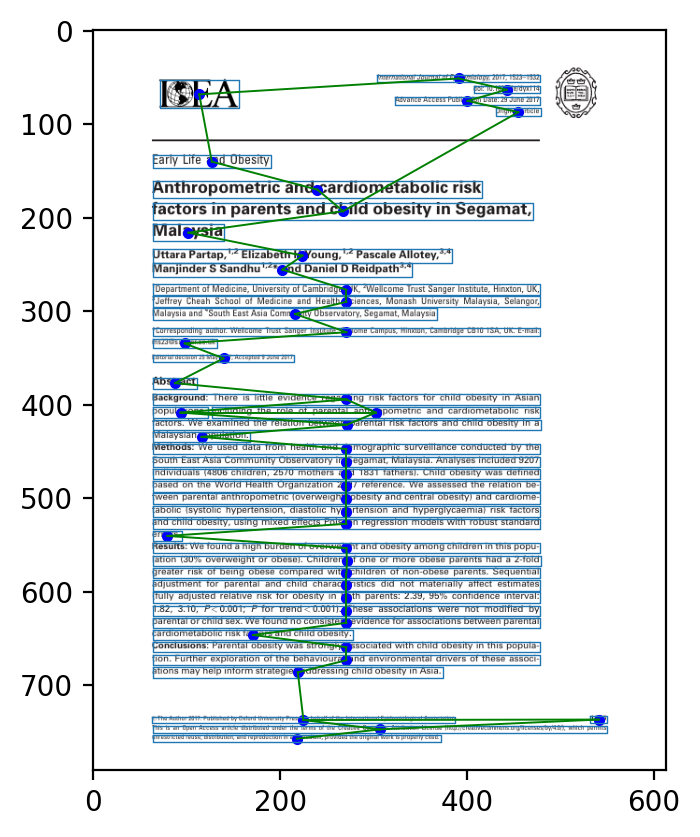

In [7]:
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
# ploter.plot_rows(row_json)
ploter.plot_tokens(tokenizer, torch_dict)

In [8]:
json_true_regions = coco_manager.get_regions_from_json()

In [9]:
file_names = list(json_true_regions.keys())
file_names.sort()

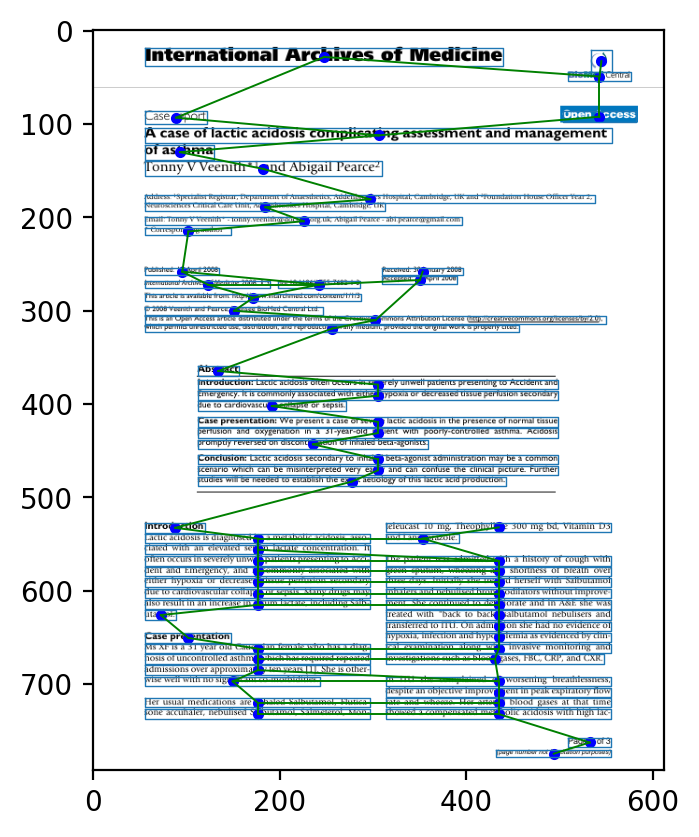

In [10]:
num_file = 1
file_name = file_names[num_file]
dataset_file = os.path.join(dataset_path, file_name)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(dataset_file, num_page=0)
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
torch_dict = tokenizer(row_json)
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
ploter.plot_tokens(tokenizer, torch_dict)

# Конвертер

In [11]:
from pager.page_model.sub_models import BaseConverter, RegionModel, RowsModel
from pager.page_model.sub_models.dtype import ImageSegment, Region, Graph
from pager import MergeExtractor


CLASSES = {1: 'text', 2: 'header', 3: 'text', 4: 'table', 5: 'figure', 0: 'other'}

class Rows2Regions(BaseConverter):
    def __init__(self, conf):
        self.rows2regionsGLAM_tokenizer = conf['tokenizer']# manager_model.get_model("rowGLAM-tokenizer")
        self.rows2regionsGLAM = conf['model']#
        self.is_merge_extract =  conf['is_merge_extract']
        self.merge_extract = MergeExtractor()

        
    def convert(self, input_model: RowsModel, output_model: RegionModel):
        page_json = input_model.to_dict()
        region_list = self.get_region(page_json['rows'])
        output_model.from_dict({"regions": region_list})

        if self.is_merge_extract:
            self.merge_extract.extract(output_model)
        # сортировка после создания региона
        # sorter = RegionSorterCutXYExtractor()
        # sorter.extract(output_model)

    def get_region(self, rows_json):
        graph_dict_torch = self.rows2regionsGLAM_tokenizer(rows_json)
        result = self.rows2regionsGLAM(graph_dict_torch)
        result['deleted_edges'] = result['E_pred'] < 0.5
        
        graph = graph_dict_torch['inds']
        deleted_edges = result['deleted_edges']
        node_classes = result['node_classes']
        regions = self.regions_from_graph(rows_json, graph, deleted_edges, node_classes)
        return regions
    

    def regions_from_graph(self, rows_json, graph, deleted_edges, node_classes):
        graph_ = Graph()
        regions = []
        
        for row_json in rows_json:
            segment = ImageSegment(dict_2p=row_json['segment'])
            xc, yc = segment.get_center()
            graph_.add_node(xc, yc)

        for node_i, node_j, ind in zip(graph[0], graph[1], deleted_edges):
            if not ind:
                graph_.add_edge(node_i+1, node_j+1)

        for reg in graph_.get_related_graphs():
            indexes = [node.index-1 for node in reg.get_nodes()]
            row_classes  = np.array([node_classes[i].detach().numpy() for i in indexes])
            lable = CLASSES[np.argmax(row_classes.mean(axis=0))]
            regions.append({'rows': [rows_json[i] for i in indexes], 'label': lable})
        return regions

# Модель

## Утилиты

In [259]:
import torch
from torch.nn import Linear, BCELoss, BCEWithLogitsLoss, CrossEntropyLoss, GELU, HuberLoss,ModuleList, ReLU
from torch.nn.functional import relu
from torch_geometric.nn import BatchNorm, TAGConv, GCNConv, GATConv
import random

class CustomLoss(torch.nn.Module):
    def __init__(self, params):
        super(CustomLoss, self).__init__()

        self.bce = BCEWithLogitsLoss(pos_weight=torch.tensor(params['edge_imbalance']))
        self.ce = CrossEntropyLoss(weight=torch.tensor(params['publaynet_imbalance']))
        self.edge_coef:float = params['edge_coef']
        self.node_coef:float = params['node_coef']

    def forward(self, pred_dict, dict_graph):
        e_pred = pred_dict["E_pred_logits"]
        e_true = dict_graph["true_edges"]
        e_pred = e_pred.squeeze()

        loss_edge = self.bce(e_pred, e_true)
        
        n_pred = pred_dict["node_classes"]
        
        n_true = dict_graph["true_nodes"]

        loss_node = self.ce(n_pred, n_true) 

        loss = self.edge_coef*loss_edge  +self.node_coef*loss_node
        return loss

class TorchModel(torch.nn.Module):
    
    def __init__(self, params):
        super(TorchModel, self).__init__()
        self.activations = {
            "gelu" : GELU, 
            "relu" : ReLU,
            "softmax" : torch.nn.Softmax,
            "sigmoid" : torch.nn.Sigmoid,
            }
        self.params = params
        self.sigmoid = torch.nn.Sigmoid()
        self.make_model()
        

    def forward(self, data_graph_dict):
        # Подготовка данных 
        X: torch.Tensor = data_graph_dict["X"] 
        Y: torch.Tensor = data_graph_dict["Y"]
        sp_A: torch.Tensor = data_graph_dict["sp_A"]
        A = sp_A.to_dense()
        new_A = self.build_conjugate_graph(A)
        new_sp_A = new_A.to_sparse_coo()
        inds:List[int] = data_graph_dict["inds"]
        model_type = self.params["model_type"]
        x = X

        if not(self.mlp_pred is None):
            x = self.mlp_pred(x)
        x = self.forward_gnn(x, sp_A, self.gcn_node)
        match model_type:
            case 1:
                
                Node_classes = self.mlp_node_class(x)
                Omega = torch.cat([x[inds[0]], x[inds[1]], X[inds[0]], X[inds[1]], Y],dim=1)
                Edge_pred_logits = self.mlp_edge_class(Omega)
            case 2:
                Node_classes = self.mlp_node_class(x)
                if not(self.mlp_node_post is None):
                    x = self.mlp_node_post(x)
                x = self.forward_gnn(x, sp_A, self.gcn_node_post)
                x = self.mlp_node_edge(x)
                Omega = torch.cat([x[inds[0]], x[inds[1]], X[inds[0]], X[inds[1]], Y],dim=1)
                Edge_pred_logits = self.mlp_edge_class(Omega)
            case 3:

                Node_classes = self.mlp_node_class(x)
                Omega = torch.cat([x[inds[0]], x[inds[1]], X[inds[0]], X[inds[1]], Y],dim=1)
                Omega = self.mlp_edge_pred(Omega)
                Omega = self.forward_gnn(Omega, new_sp_A, self.gcn_edge)
                Edge_pred_logits = self.mlp_edge_class(Omega)

        
        return {
            "node_classes": Node_classes, 
            "E_pred_logits": Edge_pred_logits,
            "E_pred" : self.sigmoid(Edge_pred_logits)
        }
    
    def forward_gnn(self, x, adj, gnn):
        for modlist in gnn:
            h = x
            for layer in modlist:
                if isinstance(layer, (TAGConv, GATConv, GCNConv)):
                    x = layer(x, adj)
                else:
                    x = layer(x)

            if self.params['concat_gcn']:
                z = torch.concat([h, x], dim = -1)
            else:
                z = x
            x = z
        return x
    
    def make_model(self):
        model_type = self.params["model_type"]

        dim = self.params["node_featch"]
        self.mlp_pred, dim = (None, dim) if self.params["mlp_pred"] is None else self.build_mlp_layer(self.params["mlp_pred"], dim)
        match model_type:
            case 1:
                print(dim)
                self.gcn_node, dim = self.build_gcn_layer(self.params["gcn_node"], dim)
                self.mlp_node_class, _ = self.build_mlp_layer(self.params["mlp_node_class"], dim)
                dim = self.params["node_featch"] * 2 + self.params["edge_featch"] + dim * 2
                self.mlp_edge_class, _ = self.build_mlp_layer(self.params["mlp_edge_class"], dim)
            case 2:
                
                self.gcn_node, dim = self.build_gcn_layer(self.params["gcn_node"], dim)
                self.mlp_node_class, _ = self.build_mlp_layer(self.params["mlp_node_class"], dim)
                self.mlp_node_post, dim = (None, dim) if self.params["mlp_node_post"] is None else self.build_mlp_layer(self.params["mlp_node_post"], dim)
                self.gcn_node_post, dim = self.build_gcn_layer(self.params["gcn_node_post"], dim)
                self.mlp_node_edge, dim = self.build_mlp_layer(self.params["mlp_node_edge"], dim)
                dim = self.params["node_featch"] * 2 + self.params["edge_featch"] + dim * 2
                self.mlp_edge_class, _ = self.build_mlp_layer(self.params["mlp_edge_class"], dim)
            case 3:

                self.gcn_node, dim = self.build_gcn_layer(self.params["gcn_node"], dim)
                self.mlp_node_class, _ = self.build_mlp_layer(self.params["mlp_node_class"], dim)
                dim = self.params["node_featch"] * 2 + self.params["edge_featch"] + dim * 2
                self.mlp_edge_pred, dim = (None, dim) if self.params["mlp_edge_pred"] is None else self.build_mlp_layer(self.params["mlp_edge_pred"], dim)
                self.gcn_edge, dim = self.build_gcn_layer(self.params["gcn_edge"], dim)
                self.mlp_edge_class, _ = self.build_mlp_layer(self.params["mlp_edge_class"], dim)


    def build_mlp_layer(self, layers, dim):
        seq = []
        for layer in layers:
            seq.append(Linear(dim, layer["out"]))

            if layer["batch_norm"]:
                seq.append(BatchNorm(layer["out"]))

            if not layer["activation"] is None:
                seq.append(self.activations[layer["activation"]]())
            dim = layer["out"]


        return torch.nn.Sequential(*seq), dim

    def build_gcn_layer(self, layers, tdim):
        module_lists = []
        dim = tdim
        for layer in layers:
            temp_list = []
            startdim = dim
            if not(layer["linear_in"] == 0):
                temp_list.append(Linear(dim, layer["linear_out"]))
                dim = layer["linear_out"]

            if layer["batch_norm"]:
                temp_list.append(BatchNorm(dim))

            if not layer["activation"] is None:
                temp_list.append(self.activations[layer["activation"]]())

            if layer["aggregation"] == "tag":
                temp_list.append(TAGConv(dim, layer["size"], K = layer["K"]))
            elif layer["aggregation"] == "gat":
                temp_list.append(GATConv(dim, layer["size"]))
            elif layer["aggregation"] == "conv":
                temp_list.append(GCNConv(dim, layer["size"]))

            module_lists.append(ModuleList(temp_list))
            if self.params['concat_gcn']:
                dim = startdim + layer['size']
            else:
                dim = layer['size']

        return ModuleList(module_lists), dim

    def build_conjugate_graph(self, A:torch.Tensor):
        A.fill_diagonal_(0)
        A = np.array(A)
        g = nx.from_numpy_array(A)
        L = nx.line_graph(g)
        A_new = torch.tensor(nx.adjacency_matrix(L).toarray())
        A_new.fill_diagonal_(1)
        return A_new.float()



# Сохранение датасета

In [252]:
from pager.page_model.sub_models.dtype import ImageSegment


def get_true_edges(token, rows, region_segs, region_categories):
    def is_one_region(row_seg_1, row_seg_2, region_segs):
        for i, reg in enumerate(region_segs):
            if reg.is_intersection(row_seg_1):
                if reg.is_intersection(row_seg_2):
                    return 1
                else:
                    return 0
        return 0

    def get_category(seg, region_segs, region_categories):
        for r, c in zip(region_segs, region_categories):
            if seg.is_intersection(r):
                return c
        return None

    def get_mini_seg(r):
        img_seg = ImageSegment(dict_2p=r)
        if img_seg.height < 5:
            return img_seg
        delta =  int(img_seg.height/5)
        img_seg.y_bottom_right = img_seg.y_bottom_right - delta
        img_seg.y_top_left = img_seg.y_top_left + delta
        return img_seg
    row_segments = [get_mini_seg(row['segment']) for row in rows]
    A = token['inds']
    true_edges = [is_one_region(row_segments[i], row_segments[j], region_segs) for i, j in zip(A[0], A[1])]
    true_nodes = [get_category(row_seg, region_segs, region_categories) for row_seg in row_segments]
    return true_edges, true_nodes

def pdf2torch_dict(path_pdf, coco_dict_file):
        try:
            pdf_json = pdf_manager.get_json_from_pdf(path_pdf, num_page=0)
            row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
        except:
            print(path_pdf, '\n')
            return {}
        torch_dict = tokenizer(row_json)
        coef_w, coef_h = 1, 1
        coco_dict_file['regions'] = [r for r in coco_dict_file['regions'] if r['segment']['height'] > 0]
        reg_segments = [ImageSegment(dict_p_size={
            "x_top_left": int(r['segment']['x_top_left']*coef_w),
            "y_top_left": int(r['segment']['y_top_left']*coef_h),
            "width": int(r['segment']['width']*coef_w),
            "height": int(r['segment']['height']*coef_h)}) for r in coco_dict_file['regions']]
        reg_categories = [r['category_id'] for r in coco_dict_file['regions']]
        true_edges, true_nodes = get_true_edges(torch_dict, row_json, reg_segments, reg_categories)
        
        del torch_dict['sp_A']
        torch_dict['true_edges'] = true_edges
        torch_dict['true_nodes'] = true_nodes

        return torch_dict
         
        print(f"{(i+1)/N*100:4.2f} %", end='\r')

dataset = GLAMDataset({
    "loger": loger,
    "pdf_dir": dataset_path,
    "coco_file": coco_path,
    "count_class": 6,
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
})

# Создание Cache
N = len(dataset)
for i, d in enumerate(dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

# Отрисовска файла из датасета

Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported


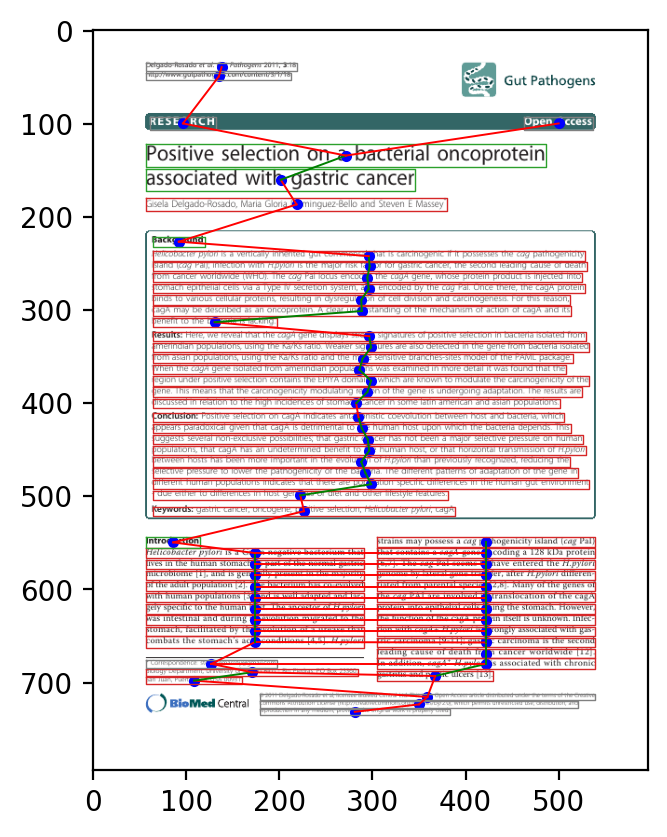

In [253]:
torch_dict2 = dataset[123]
path_pdf = os.path.join(dataset_path, torch_dict2['file_name'] + ".pdf")
_, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
ploter.plot_tokens(tokenizer, torch_dict2, markup=True)

# Регионы --------------------------------------------------------------
# ann = coco_manager.get_regions_from_json()
# regions = ann[torch_dict2['file_name'] + ".pdf"]['regions']

# for reg in regions:
#     seg = ImageSegment(dict_p_size=reg['segment'])
#     seg.plot()

# Параметры модели

In [254]:
GLAM_MODEL = 'row2region_GLAM_artic'
PARAMS  = {
    "node_featch": 15,
    "edge_featch": 4,
    "epochs": 30,
    "batch_size": 30,
    "learning_rate": 0.001,
    "model_type" : 2,
    "concat_gcn" : True,
    "mlp_pred":[
         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 256},
         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 128}],
    "gcn_node":
        [
        {"linear_in" : -1, # default -1: Повторить размерность прошлых слоев. 0 - не нужен линейный слой, в таком случае на Linear_out программа не обращает внимания 
        "batch_norm" : True, 
        "activation" : "gelu", 
        "aggregation" : "tag", 
        "K" : 3, # Опционально, только проверяется только если tag
        "linear_out" : 256, 
        "size":128},

        {"linear_in" : -1, 
        "batch_norm" : True, 
        "activation" : "gelu", 
        "K" : 3,
        "aggregation" : "tag", 
        "linear_out" : 256, 
        "size":64}
        ],

    "mlp_node_class":[
         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 128},
         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "softmax",
         "out" : 6}],
    "mlp_node_post": None, 
    "gcn_node_post":
        [
        {"linear_in" : -1, # default -1: Повторить размерность прошлых слоев. 0 - не нужен линейный слой, в таком случае на Linear_out программа не обращает внимания 
        "batch_norm" : True, 
        "activation" : "gelu", 
        "aggregation" : "tag", 
        "K" : 3, # Опционально, только проверяется только если tag
        "linear_out" : 256, 
        "size":128},

        {"linear_in" : -1, 
        "batch_norm" : True, 
        "activation" : "gelu", 
        "K" : 3,
        "aggregation" : "tag", 
        "linear_out" : 256, 
        "size":128}
        ],

    "mlp_node_edge":
    [
         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 128},

         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : None,
         "out" : 128}],
         
    "mlp_edge_class":
    [
         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 64},

         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : None,
         "out" : 1}],

    "seg_k": 0.5,
    "loss_params": {
        "edge_coef": 0.8,
        "node_coef": 0.2,
    },
    "sigmoidEdge": False,
    "NodeClasses": 6
}

In [255]:
# Дисбаланс классов ------------------------------------
import numpy as np
positiv = []
negativ = []

positiv_nodes = []
negativ_nodes = []
k = 0
for g in dataset:
    if not "true_edges" in g or not "true_nodes" in g:
        continue 
    M = len(g['true_edges'])
    p = sum(g['true_edges'])
    n = M - p
    positiv.append(p)
    negativ.append(n)

    M = len(g['true_nodes'])
    nodes = np.array(g['true_nodes'])
    pp = nodes.sum(axis=0)
    if type(pp) is np.float32:
        continue
    nn = M - pp
    
    positiv_nodes.append(pp)
    negativ_nodes.append(nn)
    

P = np.mean(positiv)
N = np.mean(negativ)
PP = np.mean(positiv_nodes, axis=0)
NN = np.mean(negativ_nodes, axis=0)
disb_nodes = NN/PP
disb_nodes[PP == 0.0] = 0
# disb_nodes = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
print(PP)
PARAMS['loss_params']['publaynet_imbalance'] = (disb_nodes/sum(disb_nodes)).tolist()
disb = N/P
print(disb)
PARAMS['loss_params']['edge_imbalance'] = float(disb)
PARAMS

/var/folders/yx/qj7wp_45401glcvln9dwv7940000gn/T/ipykernel_39694/3156289910.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  nodes = np.array(g['true_nodes'])


[12.754755  62.044044   2.2862864  0.7497497 55.7978     3.188188 ]
0.3399876


{'node_featch': 15,
 'edge_featch': 4,
 'epochs': 30,
 'batch_size': 30,
 'learning_rate': 0.001,
 'model_type': 2,
 'concat_gcn': True,
 'mlp_pred': [{'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 256},
  {'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 256},
  {'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 128}],
 'gcn_node': [{'linear_in': -1,
   'batch_norm': True,
   'activation': 'gelu',
   'aggregation': 'tag',
   'K': 3,
   'linear_out': 256,
   'size': 128},
  {'linear_in': -1,
   'batch_norm': True,
   'activation': 'gelu',
   'K': 3,
   'aggregation': 'tag',
   'linear_out': 256,
   'size': 64}],
 'mlp_node_class': [{'in': -1,
   'batch_norm': True,
   'activation': 'gelu',
   'out': 256},
  {'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 128},
  {'in': -1, 'batch_norm': True, 'activation': 'softmax', 'out': 6}],
 'mlp_node_post': None,
 'gcn_node_post': [{'linear_in': -1,
   'batch_norm': True,
   'activation': 'gelu',
   'ag

# Обучение модели

In [256]:
model:torch.nn.Module = TorchModel(PARAMS)
total_params = sum(p.numel() for p in model.parameters())  
print(f"Number of parameters: {total_params}") 

Number of parameters: 1267669


In [257]:
import time

def validation(model, batch, criterion):     
    return step(model, batch, optimizer=None, criterion=criterion, train=False)

def split_index_train_val(dataset, val_split=0.2, shuffle=True, seed=1234,batch_size=64):
    N = len(dataset)
    count_batchs = int(N*(1-val_split))//batch_size
    count_val_batch = int(N*(val_split))//batch_size
    train_size = count_batchs * batch_size 
    indexs = [i for i in range(N)]
    if shuffle:
        np.random.shuffle(indexs)
    train_indexs = indexs[:train_size]
    val_indexs = indexs[train_size:]
    batchs_train_indexs = [[train_indexs[k*batch_size+i] for i in range(batch_size)] for k in range(count_batchs)]
    batchs_val_indexs = [[val_indexs[k*batch_size+i] for i in range(batch_size)] for k in range(count_val_batch)]
    return batchs_train_indexs, batchs_val_indexs    

def step(model: torch.nn.Module, batch, optimizer, criterion, train=True):
    if train:
        optimizer.zero_grad()
    my_loss_list = []
   
    for j, data_graph_dict in enumerate(batch):
        # try:
        if data_graph_dict is None:
            continue
        pred_graph_dict = model(data_graph_dict)
        loss = criterion(pred_graph_dict, data_graph_dict)
        my_loss_list.append(loss.item())
        print(f"{(j+1)/len(batch)*100:.2f} % Batch loss={my_loss_list[-1]:.4f}" + " "*40, end="\r")
        # except Exception as e:
        #     print(e)
        #     if "Y" in data_graph_dict.keys():
        #         print(np.array(data_graph_dict['Y']).shape)
        #     if "X" in data_graph_dict.keys():
        #         print(np.array(data_graph_dict['X']).shape)
        #     continue
        if train:  
            loss.backward()
    if train:
        optimizer.step()
    return np.mean(my_loss_list)

def train_model(params, model, dataset, save_frequency=5, start_epoch=0):  
    optimizer = torch.optim.Adam(
    list(model.parameters()),
    lr=params["learning_rate"],
    )
    criterion = CustomLoss(params["loss_params"]) 

    model.to(device)
    criterion.to(device)

    loss_list = []
    start = time.time()
    train_dataset, val_dataset = split_index_train_val(dataset, val_split=0.1, batch_size=params["batch_size"])
    for k in range(start_epoch, params["epochs"]):
        my_loss_list = []
        if k == start_epoch:
            start = time.time()
        for l, batch_indexs in enumerate(train_dataset):
            batch = [dataset[ind] for ind in batch_indexs]
            batch_loss = step(model, batch, optimizer, criterion)
            my_loss_list.append(batch_loss)
            print(f"Batch # {l+1} loss={my_loss_list[-1]:.4f}" + " "*40, end='\r')
            if (k == start_epoch and l==0):
                print(f"Время обучения batch'а {time.time()-start:.2f} сек")
        train_val = np.mean(my_loss_list)
        loss_list.append(train_val)

        my_loss_list = []
        for l, batch_indexs in enumerate(val_dataset):
            batch = [dataset[ind] for ind in batch_indexs]
            batch_loss = validation(model, batch, criterion)
            my_loss_list.append(batch_loss)
            print(f"Batch # {l+1} loss={my_loss_list[-1]:.4f}" + " "*40, end='\r')
        validation_val =  np.mean(my_loss_list)
        print("="*10, f"EPOCH #{k+1}","="*10, f"({train_val:.4f}/{validation_val:.4f})")
        if k == start_epoch:
            print(f"Время обучения epoch {time.time()-start:.2f} сек")    
            
        loger(f"EPOCH #{k}\t {train_val:.8f} (VAL: {validation_val:.8f})")  
        if (k+1) % save_frequency == 0:
            num = k//save_frequency
            torch.save(model.state_dict(), GLAM_MODEL+f"_tmp_{num}")
    loger(f"Время обучения: {time.time()-start:.2f} сек")
    torch.save(model.state_dict(), GLAM_MODEL)


def load_checkpoint(model, path_model,restart_num=None):
    dir_model = os.path.dirname(path_model)
    name_model = os.path.basename(path_model)
    names = [n for n in os.listdir(dir_model) if name_model+'_tmp_' in n]
    if restart_num is None:
        list_num = [int(n.split("_tmp_")[-1]) for n in names]
        if len(list_num) == 0:
            return
        restart_num = max(list_num) 

    checkpoint_path = os.path.join(dir_model, name_model+f"_tmp_{restart_num}")
    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    print(checkpoint_path)
    return restart_num

In [258]:
SAVE_FREQUENCY = 5
device = 'cpu'
if __name__ == "__main__":
    is_restart = False
    restart_num = None
    if is_restart:
        loger("R E S T A R T ")
    loger.time_log()
    try:
        str_ = dataset.__str__()
        str_ += '\n'.join(f"{key}:\t{val}" for key, val in PARAMS.items())
        print(str_)
        if not is_restart:
            loger(str_)
    except:
        print(dataset)
    PARAMS['sigmoidEdge'] = False
    model:torch.nn.Module = TorchModel(PARAMS)
    if is_restart:
        restart_num = load_checkpoint(model, GLAM_MODEL)
    
    start_epoch = 0 if restart_num is None else (restart_num+1)*SAVE_FREQUENCY
    train_model(PARAMS, model, dataset, save_frequency=SAVE_FREQUENCY, start_epoch=start_epoch)

DATASET INFO:
count row: 999
first: dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
	 A:torch.Size([83, 83])
	 nodes_feature:torch.Size([83, 15])
	 edges_feature:torch.Size([114, 4])
	 true_edges:torch.Size([114])
end:dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
	 A:torch.Size([154, 154])
	 nodes_feature:torch.Size([154, 15])
	 edges_feature:torch.Size([242, 4])
	 true_edges:torch.Size([242])

node_featch:	15
edge_featch:	4
epochs:	30
batch_size:	30
learning_rate:	0.001
model_type:	2
concat_gcn:	True
mlp_pred:	[{'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 256}, {'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 256}, {'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 128}]
gcn_node:	[{'linear_in': -1, 'batch_norm': True, 'activation': 'gelu', 'aggregation': 'tag', 'K': 3, 'linear_out': 256, 'size': 128}, {'linear_in': -1, 'batch_norm': True, 'activation': 'gelu', 'K': 3, 'aggrega

/var/folders/yx/qj7wp_45401glcvln9dwv7940000gn/T/ipykernel_39694/1690293670.py:188: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  A = np.array(A)
/Users/mike/lab/rows2regionsGLAM/.venv/lib/python3.14/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/Users/mike/lab/rows2regionsGLAM/.venv/lib/python3.14/site-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call

Время обучения batch'а 0.31 сек                                   
========== EPOCH #1 ========== (0.2241/0.2007)                    
Время обучения epoch 9.71 сек
tensor([0.3715, 0.2845, 0.3695, 0.6019, 0.1867, 0.6393, 0.6068, 0.6630, 0.1897,
        0.6362, 0.6752, 0.1929, 0.6429, 0.6561, 0.1977, 0.6945, 0.6726, 0.1969,
        0.6926, 0.6890, 0.3526, 0.1974, 0.6808, 0.2144, 0.6873, 0.1873, 0.4155,
        0.6862, 0.4917, 0.4538, 0.6824, 0.7180, 0.1959, 0.6676, 0.1974, 0.3117,
        0.4427, 0.7116, 0.6903, 0.3258, 0.5130, 0.7117, 0.1961, 0.7349, 0.7077,
        0.1949, 0.7360, 0.6979, 0.1924, 0.7382, 0.7010, 0.1918, 0.7334, 0.7088,
        0.1942, 0.7444, 0.6885, 0.2993, 0.7115, 0.1885, 0.6822, 0.2134, 0.2390,
        0.1595, 0.6844, 0.6517, 0.2148, 0.7019, 0.2278, 0.7000, 0.1747, 0.2637,
        0.7195, 0.1813, 0.7298, 0.6421, 0.2014, 0.7478, 0.6783, 0.6861, 0.1781,
        0.7616, 0.7588, 0.1938, 0.6939, 0.7576, 0.1946, 0.7054, 0.2003, 0.7618,
        0.3362, 0.7060, 0.7623, 0.15

KeyboardInterrupt: 

# Проверка работы модели

In [249]:
PARAMS['sigmoidEdge'] = True
model = TorchModel(PARAMS)
model.load_state_dict(torch.load(GLAM_MODEL, weights_only=True))

rows_model = RowsModel()
region_model = RegionModel()
rows2regions = Rows2Regions({
    'model':model, 
    'tokenizer': RowGLAMTokenizer(),
    'is_merge_extract': True
})

AttributeError: 'TorchModel' object has no attribute 'self'

NameError: name 'rows_model' is not defined

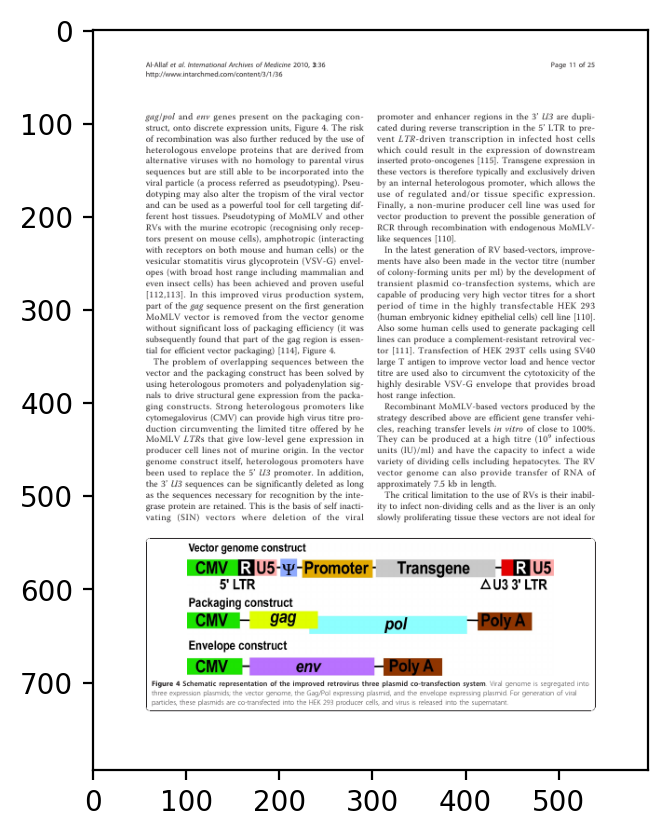

In [250]:
torch_dict2 = dataset[78]
path_pdf = os.path.join(dataset_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions.convert(rows_model, region_model)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [ ]:
from rows2regionsGLAM.metrics import GridMetric
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [ ]:
test_dataset = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": test_path,
    "coco_file": test_coco_path,
    "count_class": 6,
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
    }
)

In [ ]:
COUNT_TEST_SIZE = 200
loger("Start Test")
loger.time_log()

N = len(test_dataset)
for i, d in enumerate(test_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

In [ ]:
import numpy as np
from pager import ImageSegment

def get_bbox(segment, resize = None, delta_w = 0, delta_h = 0):
    coef_w, coef_h = 1, 1
    if resize:
        coef_w, coef_h = resize
    if not "height" in segment:
        segment['width'] = segment['x_bottom_right']-segment['x_top_left']
        segment['height']= segment['y_bottom_right']-segment['y_top_left']
    return [
        int(coef_w*segment['x_top_left']-delta_w),
        int(coef_h*segment['y_top_left']-delta_h),
        int(coef_w*segment['width']+delta_w),
        int(coef_h*segment['height']+delta_h)
    ]

def clean_rows(rows, bboxes_true):
    def is_row_in_region(row, segs_regions):
        for r in segs_regions:
            if row.is_intersection(r):
                return True
        return False
    def is_good_block(block):
        h = block['segment']['y_bottom_right']-block['segment']['y_top_left']
        w = block['segment']['x_bottom_right']-block['segment']['x_top_left']
        return h > 3 and w > 3
        
    old_rows = [row for row in rows if is_good_block(row)]
    segs_row = [ImageSegment(dict_2p=row['segment']) for row in old_rows]
    new_rows = []
    seg_bboxes_true = [ImageSegment(dict_p_size=bbox) for bbox in bboxes_true]
    for i, row in enumerate(segs_row):
        if is_row_in_region(row, seg_bboxes_true):
            new_rows.append(old_rows[i])
    rows = new_rows

def clean_bboxes_true(bboxes_true):
    return [bbox_true for bbox_true in bboxes_true if bbox_true['height'] > 3 and bbox_true['width'] > 3]





target = []
preds = []
word_grids = []
row_grids = []
paths = []
N = len(test_dataset)
for i, d in enumerate(test_dataset):
    name_file = test_dataset.pdf_names[i]
    true_regions = test_dataset.coco_ann[name_file]['regions']
    bboxes_true = clean_bboxes_true([reg['segment'] for reg in true_regions])
    
    pdf_json = pdf_manager.get_json_from_pdf(os.path.join(test_path, name_file))
    row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
    clean_rows(row_json, bboxes_true)
    
    rows_model.from_dict({"rows": row_json})
    rows2regions.convert(rows_model, region_model)
    bboxes_pred = [reg['segment'] for reg in region_model.to_dict()['regions'] if reg['label'] != 'other']
    
    word_grids.append([get_bbox(word['segment']) for row in row_json for word in row['words']])
    row_grids.append([get_bbox(row['segment']) for row in row_json])
    target.append([get_bbox(seg) for seg in bboxes_true])
    preds.append([get_bbox(seg) for seg in bboxes_pred])

    
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

/var/folders/yx/qj7wp_45401glcvln9dwv7940000gn/T/ipykernel_53388/3308985233.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  A = np.array(A)


Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported


In [ ]:
grid_metric = GridMetric()

i = 0
N = len(preds)
for bboxes_pred, bboxes_true, grid_row, grid_word in zip(preds, target, row_grids, word_grids):
    i+=1
    try:
        grid_metric.add_pair(bboxes_pred, bboxes_true, grid_row, grid_word)
        print(f"{(i)/N*100:4.2f} %", end='\r')
    except:
        pass
grid_metric.update()        

In [ ]:
map_metric = MeanAveragePrecision(box_format="xywh")

get_category = lambda an: 1

map_metric.update([dict(     
                    boxes=torch.tensor(bboxes_pred) ,
                    scores=torch.tensor([1.0 for an in bboxes_pred]),
                    labels=torch.tensor([get_category(an) for an in bboxes_pred]),
                    ) for bboxes_pred in preds], 
                  [dict(     
                        boxes=torch.tensor(bboxes_true) ,
                        labels=torch.tensor([get_category(an) for an in bboxes_true]),
                        ) for bboxes_true in target])  
rez = map_metric.compute()
map_metric_rez = f"mAP@IoU[0.50:0.95]   :{rez['map']:.8f}"

/Users/mike/lab/rows2regionsGLAM/.venv/lib/python3.14/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


In [ ]:
print(map_metric_rez)
print(grid_metric)
loger("Test Result")
loger(map_metric_rez)
loger(grid_metric.__str__())

mAP@IoU[0.50:0.95]   :0.34307665
threshold_05--------------------
precision_row       :0.7664
recall_row          :0.7600
f1_row              :0.7632
precision_word      :0.7335
recall_word         :0.7282
f1_word             :0.7308
threshold_95--------------------
precision_row       :0.5998
recall_row          :0.5862
f1_row              :0.5929
precision_word      :0.5738
recall_word         :0.5639
f1_word             :0.5688



In [446]:
mAP@IoU[0.50:0.95]   :0.29383710
==================================================
threshold_05--------------------
precision_row       :0.7083
recall_row          :0.7141
f1_row              :0.7112
precision_word      :0.6765
recall_word         :0.6892
f1_word             :0.6828
threshold_95--------------------
precision_row       :0.5514
recall_row          :0.5596
f1_row              :0.5555
precision_word      :0.5242
recall_word         :0.5341
f1_word             :0.5291


SyntaxError: illegal target for annotation (1711598841.py, line 1)